In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import linregress

In [7]:
fund_master = pd.read_csv(
    "/content/drive/MyDrive/Mutual fund_project/Data/01_fund_master.csv"
)

nav = pd.read_csv(
    "/content/drive/MyDrive/Mutual fund_project/Data/02_nav_history.csv"
)

performance = pd.read_csv(
    "/content/drive/MyDrive/Mutual fund_project/Data/07_scheme_performance.csv"
)

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import linregress

In [10]:
fund_master = pd.read_csv(
    "/content/drive/MyDrive/Mutual fund_project/Data/01_fund_master.csv"
)

nav_df = pd.read_csv(
    "/content/drive/MyDrive/Mutual fund_project/Data/02_nav_history.csv"
)

performance = pd.read_csv(
    "/content/drive/MyDrive/Mutual fund_project/Data/07_scheme_performance.csv"
)

print("Fund Master:", fund_master.shape)
print("NAV History:", nav_df.shape)
print("Performance:", performance.shape)

Fund Master: (40, 15)
NAV History: (46000, 3)
Performance: (40, 19)


In [11]:
nav_df = nav_df.merge(
    fund_master[['amfi_code', 'scheme_name']],
    on='amfi_code',
    how='left'
)

print(nav_df.head())

   amfi_code        date      nav                                scheme_name
0     119551  2022-01-03  54.3856  SBI Bluechip Fund - Regular Plan - Growth
1     119551  2022-01-04  54.3474  SBI Bluechip Fund - Regular Plan - Growth
2     119551  2022-01-05  54.6869  SBI Bluechip Fund - Regular Plan - Growth
3     119551  2022-01-06  55.4550  SBI Bluechip Fund - Regular Plan - Growth
4     119551  2022-01-07  55.3692  SBI Bluechip Fund - Regular Plan - Growth


In [12]:
nav_df['date'] = pd.to_datetime(nav_df['date'])

print(nav_df.dtypes)

amfi_code               int64
date           datetime64[ns]
nav                   float64
scheme_name            object
dtype: object


In [13]:
nav_df = nav_df.sort_values(
    ['scheme_name', 'date']
)

nav_df.head()

,amfi_code,date,nav,scheme_name
32200,101206,2022-01-03,305.0996,ABSL Frontline Equity Fund - Regular - Growth
32201,101206,2022-01-04,305.4514,ABSL Frontline Equity Fund - Regular - Growth
32202,101206,2022-01-05,306.6324,ABSL Frontline Equity Fund - Regular - Growth
32203,101206,2022-01-06,305.9800,ABSL Frontline Equity Fund - Regular - Growth
32204,101206,2022-01-07,304.0480,ABSL Frontline Equity Fund - Regular - Growth


In [14]:
nav_df['daily_return'] = (
    nav_df.groupby('scheme_name')['nav']
          .pct_change()
)

nav_df.head()

,amfi_code,date,nav,scheme_name,daily_return
32200,101206,2022-01-03,305.0996,ABSL Frontline Equity Fund - Regular - Growth,NaN
32201,101206,2022-01-04,305.4514,ABSL Frontline Equity Fund - Regular - Growth,0.001153
32202,101206,2022-01-05,306.6324,ABSL Frontline Equity Fund - Regular - Growth,0.003866
32203,101206,2022-01-06,305.9800,ABSL Frontline Equity Fund - Regular - Growth,-0.002128
32204,101206,2022-01-07,304.0480,ABSL Frontline Equity Fund - Regular - Growth,-0.006314


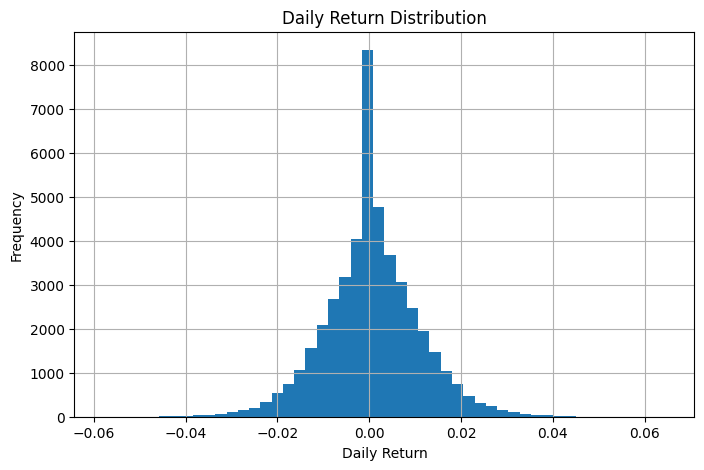

In [15]:
plt.figure(figsize=(8,5))

nav_df['daily_return'].dropna().hist(
    bins=50
)

plt.title("Daily Return Distribution")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

In [16]:
nav_df.to_csv(
    "/content/drive/MyDrive/Mutual fund_project/nav_with_returns.csv",
    index=False
)

print("File saved successfully")

File saved successfully


In [17]:
print(nav_df.columns)

print(nav_df.shape)

nav_df.head()

Index(['amfi_code', 'date', 'nav', 'scheme_name', 'daily_return'], dtype='object')
(46000, 5)


,amfi_code,date,nav,scheme_name,daily_return
32200,101206,2022-01-03,305.0996,ABSL Frontline Equity Fund - Regular - Growth,NaN
32201,101206,2022-01-04,305.4514,ABSL Frontline Equity Fund - Regular - Growth,0.001153
32202,101206,2022-01-05,306.6324,ABSL Frontline Equity Fund - Regular - Growth,0.003866
32203,101206,2022-01-06,305.9800,ABSL Frontline Equity Fund - Regular - Growth,-0.002128
32204,101206,2022-01-07,304.0480,ABSL Frontline Equity Fund - Regular - Growth,-0.006314


In [19]:
import pandas as pd
import numpy as np

cagr_results = []

for scheme, group in nav_df.groupby('scheme_name'):

    group = group.sort_values('date')

    start_nav = group['nav'].iloc[0]
    end_nav = group['nav'].iloc[-1]

    years = (
        (group['date'].iloc[-1] -
         group['date'].iloc[0]).days
    ) / 365.25

    cagr = (
        (end_nav / start_nav) ** (1 / years) - 1
    ) * 100

    cagr_results.append(
        [scheme, round(cagr, 2)]
    )

cagr_df = pd.DataFrame(
    cagr_results,
    columns=['Scheme', 'CAGR (%)']
)

cagr_df = cagr_df.sort_values(
    'CAGR (%)',
    ascending=False
)

cagr_df.head(10)

,Scheme,CAGR (%)
18,ICICI Pru Midcap Fund - Regular - Growth,32.83
36,SBI Small Cap Fund - Regular Plan - Growth,32.42
8,DSP Small Cap Fund - Regular - Growth,32.29
26,Mirae Asset Tax Saver Fund - Regular - Growth,31.95
25,Mirae Asset Large Cap Fund - Regular - Growth,30.97
22,Kotak Flexicap Fund - Regular - Growth,30.91
11,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,30.12
7,DSP Midcap Fund - Regular - Growth,29.58
5,Axis Midcap Fund - Regular - Growth,28.21
33,SBI Bluechip Fund - Regular Plan - Growth,25.80


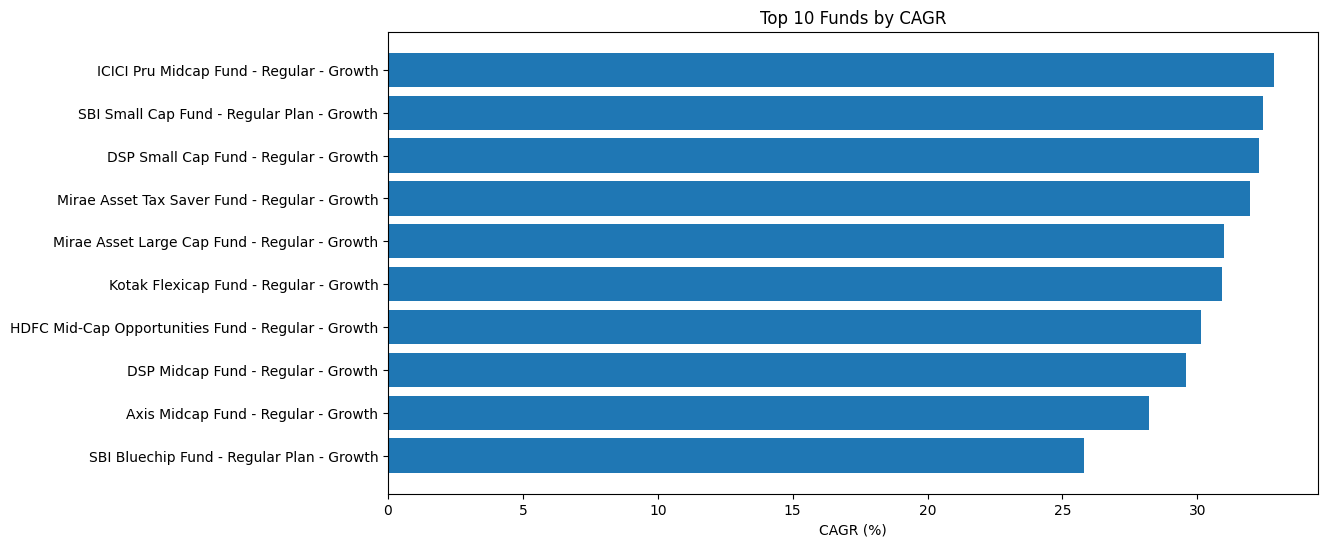

In [20]:
import matplotlib.pyplot as plt

top10 = cagr_df.head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top10['Scheme'],
    top10['CAGR (%)']
)

plt.title("Top 10 Funds by CAGR")

plt.xlabel("CAGR (%)")

plt.gca().invert_yaxis()

plt.show()

In [21]:
cagr_df.to_csv(
    "/content/drive/MyDrive/Mutual fund_project/cagr_results.csv",
    index=False
)

print("CAGR results saved")

CAGR results saved


In [22]:
cagr_df.head()

,Scheme,CAGR (%)
18,ICICI Pru Midcap Fund - Regular - Growth,32.83
36,SBI Small Cap Fund - Regular Plan - Growth,32.42
8,DSP Small Cap Fund - Regular - Growth,32.29
26,Mirae Asset Tax Saver Fund - Regular - Growth,31.95
25,Mirae Asset Large Cap Fund - Regular - Growth,30.97


In [23]:
volatility_df = (
    nav_df.groupby('scheme_name')['daily_return']
          .std()
          .reset_index()
)

volatility_df.columns = [
    'Scheme',
    'Volatility'
]

volatility_df['Volatility (%)'] = (
    volatility_df['Volatility'] * 100
)

volatility_df = volatility_df.sort_values(
    'Volatility (%)',
    ascending=False
)

volatility_df.head()

,Scheme,Volatility,Volatility (%)
2,ABSL Small Cap Fund - Regular - Growth,0.016251,1.625079
31,Nippon India Small Cap Fund - Regular - Growth,0.015901,1.590066
36,SBI Small Cap Fund - Regular Plan - Growth,0.015837,1.583708
6,Axis Small Cap Fund - Regular - Growth,0.015790,1.579046
35,SBI Small Cap Fund - Direct Plan - Growth,0.015717,1.571710


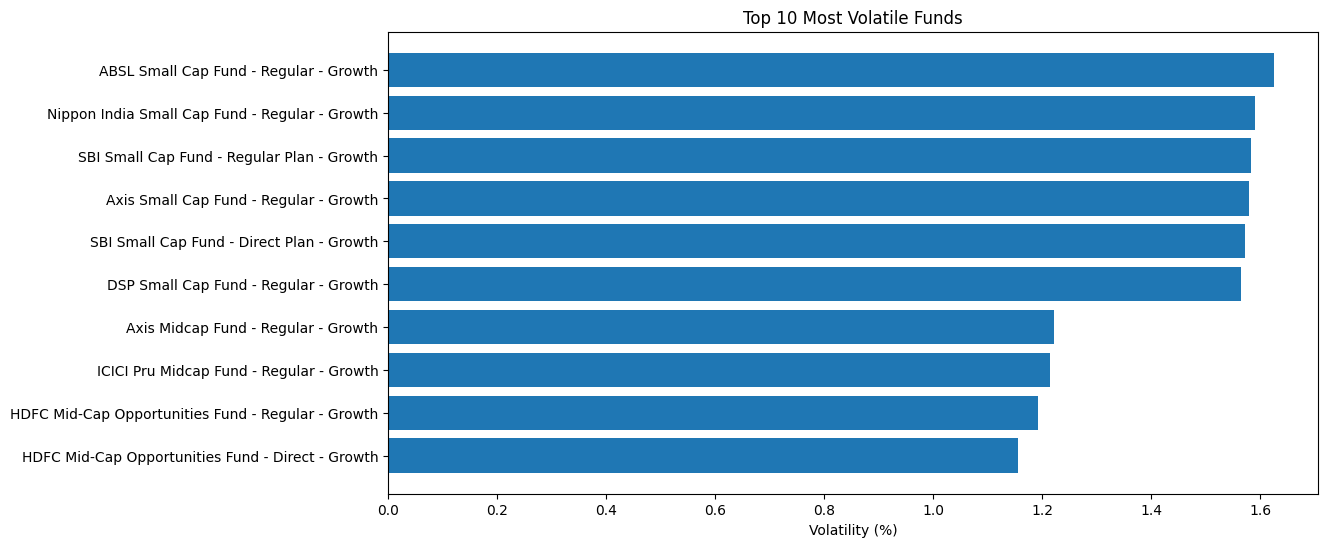

In [24]:
top10_vol = volatility_df.head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top10_vol['Scheme'],
    top10_vol['Volatility (%)']
)

plt.title("Top 10 Most Volatile Funds")

plt.xlabel("Volatility (%)")

plt.gca().invert_yaxis()

plt.show()

In [25]:
volatility_df.to_csv(
    "/content/drive/MyDrive/Mutual fund_project/volatility_results.csv",
    index=False
)

print("Volatility results saved")

Volatility results saved


In [26]:
performance[
    ['scheme_name','sharpe_ratio']
].sort_values(
    'sharpe_ratio',
    ascending=False
).head(10)

,scheme_name,sharpe_ratio
14,ICICI Pru Liquid Fund - Regular - Growth,7.68
23,Kotak Liquid Fund - Regular - Growth,6.18
30,ABSL Liquid Fund - Regular - Growth,5.14
9,HDFC Short Term Debt Fund - Regular - Growth,1.84
4,SBI Magnum Gilt Fund - Regular Plan - Growth,1.52
19,Nippon India Gilt Securities Fund - Regular - ...,1.33
34,Mirae Asset Large Cap Fund - Regular - Growth,1.06
5,HDFC Top 100 Fund - Regular Plan - Growth,1.06
11,ICICI Pru Bluechip Fund - Direct - Growth,1.03
15,Nippon India Large Cap Fund - Regular - Growth,1.00


In [27]:
volatility_df.head()

,Scheme,Volatility,Volatility (%)
2,ABSL Small Cap Fund - Regular - Growth,0.016251,1.625079
31,Nippon India Small Cap Fund - Regular - Growth,0.015901,1.590066
36,SBI Small Cap Fund - Regular Plan - Growth,0.015837,1.583708
6,Axis Small Cap Fund - Regular - Growth,0.015790,1.579046
35,SBI Small Cap Fund - Direct Plan - Growth,0.015717,1.571710


In [30]:
sharpe_df = performance[['scheme_name', 'sharpe_ratio']]

sharpe_df = sharpe_df.sort_values(
    'sharpe_ratio',
    ascending=False
)

print(sharpe_df.head(10))

                                          scheme_name  sharpe_ratio
14           ICICI Pru Liquid Fund - Regular - Growth          7.68
23               Kotak Liquid Fund - Regular - Growth          6.18
30                ABSL Liquid Fund - Regular - Growth          5.14
9        HDFC Short Term Debt Fund - Regular - Growth          1.84
4        SBI Magnum Gilt Fund - Regular Plan - Growth          1.52
19  Nippon India Gilt Securities Fund - Regular - ...          1.33
34      Mirae Asset Large Cap Fund - Regular - Growth          1.06
5           HDFC Top 100 Fund - Regular Plan - Growth          1.06
11          ICICI Pru Bluechip Fund - Direct - Growth          1.03
15     Nippon India Large Cap Fund - Regular - Growth          1.00


In [31]:
drawdown_df = performance[
    ['scheme_name', 'max_drawdown_pct']
]

drawdown_df = drawdown_df.sort_values(
    'max_drawdown_pct'
)

print(drawdown_df.head(10))

                                          scheme_name  max_drawdown_pct
6            HDFC Top 100 Fund - Direct Plan - Growth            -33.50
35  Mirae Asset Emerging Bluechip Fund - Regular -...            -33.15
26                Axis Midcap Fund - Regular - Growth            -32.38
8   HDFC Mid-Cap Opportunities Fund - Direct - Growth            -32.22
17     Nippon India Small Cap Fund - Regular - Growth            -30.87
24              Axis Bluechip Fund - Regular - Growth            -27.54
38                 DSP Midcap Fund - Regular - Growth            -26.99
18                     Nippon India ETF Nifty 50 BeES            -26.75
11          ICICI Pru Bluechip Fund - Direct - Growth            -26.59
10         ICICI Pru Bluechip Fund - Regular - Growth            -25.91


In [32]:
scorecard = performance[
    [
        'scheme_name',
        'return_3yr_pct',
        'return_5yr_pct',
        'sharpe_ratio',
        'expense_ratio_pct',
        'morningstar_rating',
        'risk_grade'
    ]
]

scorecard.head()

,scheme_name,return_3yr_pct,return_5yr_pct,sharpe_ratio,expense_ratio_pct,morningstar_rating,risk_grade
0,SBI Bluechip Fund - Regular Plan - Growth,12.36,14.45,0.88,1.54,4,Moderate
1,SBI Bluechip Fund - Direct Plan - Growth,11.30,14.23,0.81,0.66,3,Moderate
2,SBI Small Cap Fund - Regular Plan - Growth,23.39,20.67,0.94,1.43,5,Very High
3,SBI Small Cap Fund - Direct Plan - Growth,23.14,21.82,0.93,0.72,4,Very High
4,SBI Magnum Gilt Fund - Regular Plan - Growth,6.07,5.43,1.52,0.77,5,Low


In [33]:
scorecard.to_csv(
    "/content/drive/MyDrive/Mutual fund_project/fund_scorecard.csv",
    index=False
)

drawdown_df.to_csv(
    "/content/drive/MyDrive/Mutual fund_project/drawdown_results.csv",
    index=False
)

print("Files saved successfully")

Files saved successfully


In [34]:
print("DAY 4 SUMMARY")

print("\nTop CAGR Fund:")
print(cagr_df.head(1))

print("\nBest Sharpe Ratio Fund:")
print(
    performance[
        ['scheme_name','sharpe_ratio']
    ].sort_values(
        'sharpe_ratio',
        ascending=False
    ).head(1)
)

print("\nHighest Drawdown Fund:")
print(drawdown_df.head(1))

DAY 4 SUMMARY

Top CAGR Fund:
                                      Scheme  CAGR (%)
18  ICICI Pru Midcap Fund - Regular - Growth     32.83

Best Sharpe Ratio Fund:
                                 scheme_name  sharpe_ratio
14  ICICI Pru Liquid Fund - Regular - Growth          7.68

Highest Drawdown Fund:
                                scheme_name  max_drawdown_pct
6  HDFC Top 100 Fund - Direct Plan - Growth             -33.5
